In [2]:
%%capture
%run "EDA.ipynb"


AttributeError: 'list' object has no attribute 'drop'

AttributeError: 'list' object has no attribute 'drop'

# 4.Preprocessing

In [3]:
from scipy.stats import skew

skew_values = train[numerical_features].apply(lambda x: skew(x.dropna()))
print(skew_values.sort_values(ascending=False))

annual_income           1.719504
debt_to_income_ratio    1.406676
loan_amount             0.207359
interest_rate           0.049945
credit_score           -0.166992
dtype: float64


In [4]:
skewed_cols = skew_values[abs(skew_values) > 1].index.tolist()
print("Highly skewed columns:", skewed_cols)

for col in skewed_cols:
    train[col] = np.log1p(train[col])
    test[col]  = np.log1p(test[col])

from sklearn.preprocessing import PowerTransformer

# Initialize Yeo-Johnson transformer
pt = PowerTransformer(method='yeo-johnson')

# Apply transformation to skewed columns
# train[skewed_cols] = pt.fit_transform(train[skewed_cols])
# test[skewed_cols] = pt.transform(test[skewed_cols])

Highly skewed columns: ['annual_income', 'debt_to_income_ratio']


## Outliers (IQR)

In [5]:
for col in numerical_features:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)
    test[col] = test[col].clip(lower=lower_bound, upper=upper_bound)

In [6]:
target = 'loan_paid_back'
cols = train.columns
cols = cols.drop('loan_paid_back')

## Target Encoding

In [7]:
def target_encoding(train, predict, n_splits=5):

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    mean_features_train = pd.DataFrame(index=train.index)
    mean_features_test = pd.DataFrame(index=predict.index)

    for col in cols:
        # --- K-Fold Target Mean Encoding ---
        mean_encoded = np.zeros(len(train))
        for tr_idx, val_idx in kf.split(train):
            tr_fold = train.iloc[tr_idx]
            val_fold = train.iloc[val_idx]
            mean_map = tr_fold.groupby(col)[target].mean()
            mean_encoded[val_idx] = val_fold[col].map(mean_map)

        mean_features_train[f'mean_{col}'] = mean_encoded

        # --- Apply global mean mapping to prediction/test data ---
        global_mean = train.groupby(col)[target].mean()
        mean_features_test[f'mean_{col}'] = predict[col].map(global_mean)

    # --- Concatenate new features at once to avoid fragmentation ---
    train = pd.concat([train, mean_features_train], axis=1)
    predict = pd.concat([predict, mean_features_test], axis=1)

    # Defragment
    train = train.copy()
    predict = predict.copy()
    return train, predict

train , test = target_encoding(train, test)

In [8]:
def create_frequency_features(df, df_test):

    # Pre-allocate DataFrames for new features to avoid fragmentation
    freq_features_train = pd.DataFrame(index=df.index)
    freq_features_test = pd.DataFrame(index=df_test.index)
    bin_features_train = pd.DataFrame(index=df.index)
    bin_features_test = pd.DataFrame(index=df_test.index)

    for col in cols:
        # --- Frequency encoding ---
        freq = df[col].value_counts()
        df[f"{col}_freq"] = df[col].map(freq)
        freq_features_test[f"{col}_freq"] = df_test[col].map(freq).fillna(freq.mean())

        # --- Quantile binning for numeric columns ---
        if col in numerical_features:
            for q in [5, 10, 15]:
                try:
                    train_bins, bins = pd.qcut(df[col], q=q, labels=False, retbins=True, duplicates="drop")
                    bin_features_train[f"{col}_bin{q}"] = train_bins
                    bin_features_test[f"{col}_bin{q}"] = pd.cut(df_test[col], bins=bins, labels=False, include_lowest=True)
                except Exception:
                    bin_features_train[f"{col}_bin{q}"] = 0
                    bin_features_test[f"{col}_bin{q}"] = 0

    # Concatenate all new features at once
    df = pd.concat([df, freq_features_train, bin_features_train], axis=1)
    df_test = pd.concat([df_test, freq_features_test, bin_features_test], axis=1)

    return df, df_test

train, test = create_frequency_features(train, test)

In [9]:
print(train.shape)
train.head()

(593994, 49)


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,mean_annual_income,mean_debt_to_income_ratio,mean_credit_score,mean_loan_amount,mean_interest_rate,mean_gender,mean_marital_status,mean_education_level,mean_employment_status,mean_loan_purpose,mean_grade_subgrade,annual_income_freq,debt_to_income_ratio_freq,credit_score_freq,loan_amount_freq,interest_rate_freq,gender_freq,marital_status_freq,education_level_freq,employment_status_freq,loan_purpose_freq,grade_subgrade_freq,annual_income_bin5,annual_income_bin10,annual_income_bin15,debt_to_income_ratio_bin5,debt_to_income_ratio_bin10,debt_to_income_ratio_bin15,credit_score_bin5,credit_score_bin10,credit_score_bin15,loan_amount_bin5,loan_amount_bin10,loan_amount_bin15,interest_rate_bin5,interest_rate_bin10,interest_rate_bin15
0,10.287695,0.080658,736.0,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.710526,0.847686,0.895262,0.875000,0.726531,0.802141,0.798951,0.809686,0.899948,0.802012,0.835339,51,6720,3472,57,933,306175,288843,183592,52480,63874,58695,1,2,4,1,3,5,4,8,12,0,0,0,3,7,11
1,10.003741,0.153579,636.0,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,0.923077,0.627424,0.649867,0.714286,0.710706,0.795659,0.799032,0.802114,0.894201,0.796389,0.695845,16,2677,3825,44,552,284091,277239,93097,450645,324695,36694,0,1,2,3,7,11,0,1,2,0,0,1,3,6,9
2,10.811085,0.092579,694.0,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,NaN,0.816124,0.813119,0.825000,0.915512,0.795738,0.798951,0.809686,0.894132,0.797286,0.847443,1,9508,4025,48,923,284091,288843,183592,450645,324695,53317,2,5,8,2,5,7,2,5,8,3,6,9,0,0,1
3,10.754904,0.062975,536.5,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,NaN,0.904502,0.575928,0.818182,0.747475,0.802255,0.799220,0.809999,0.894269,0.797795,0.626351,1,6114,4065,60,250,306175,288843,183592,450645,324695,5534,2,5,7,0,1,2,0,0,0,0,0,1,4,9,14
4,10.146344,0.051643,665.0,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.923077,0.914669,0.836411,0.875000,0.881429,0.795659,0.799032,0.809371,0.894201,0.802117,0.732244,19,5292,3388,78,896,284091,277239,183592,450645,63874,37029,1,2,3,0,0,1,1,3,5,1,3,5,0,1,2


# 5. Feature Engineering

In [10]:
train['loan_to_income'] = train['loan_amount'] / (train['annual_income'] + 1)
test['loan_to_income'] = test['loan_amount'] / (test['annual_income'] + 1)

train['total_debt'] = train['debt_to_income_ratio'] * train['annual_income']
test['total_debt'] = test['debt_to_income_ratio'] * test['annual_income']

train['available_income'] = train['annual_income'] * (1 - train['debt_to_income_ratio'])
test['available_income'] = test['annual_income'] * (1 - test['debt_to_income_ratio'])

train['affordability'] = train['available_income'] / (train['loan_amount'] + 1)
test['affordability'] = test['available_income'] / (test['loan_amount'] + 1)

train['monthly_payment'] = train['loan_amount'] * (1 + train['interest_rate']/100) / 12
test['monthly_payment'] = test['loan_amount'] * (1 + test['interest_rate']/100) / 12

train['payment_to_income'] = train['monthly_payment'] / (train['annual_income']/12 + 1)
test['payment_to_income'] = test['monthly_payment'] / (test['annual_income']/12 + 1)

train['risk_score'] = (train['debt_to_income_ratio'] * 40 + 
                        (1 - train['credit_score']/850) * 30 + train['interest_rate'] * 2)
test['risk_score'] = (test['debt_to_income_ratio'] * 40 + 
                       (1 - test['credit_score']/850) * 30 + test['interest_rate'] * 2)


train['credit_interest'] = train['credit_score'] * train['interest_rate'] / 100
test['credit_interest'] = test['credit_score'] * test['interest_rate'] / 100

train['income_credit'] = np.log1p(train['annual_income']) * train['credit_score'] / 1000
test['income_credit'] = np.log1p(test['annual_income']) * test['credit_score'] / 1000

train['debt_loan'] = train['debt_to_income_ratio'] * np.log1p(train['loan_amount'])
test['debt_loan'] = test['debt_to_income_ratio'] * np.log1p(test['loan_amount'])

train['log_income'] = np.log1p(train['annual_income'])
test['log_income'] = np.log1p(test['annual_income'])

train['log_loan'] = np.log1p(train['loan_amount'])
test['log_loan'] = np.log1p(test['loan_amount'])

for df in [train, test]:
     df['income_to_dti'] = df['annual_income'] / (1 + df['debt_to_income_ratio'])
     df['interest_to_score'] = df['interest_rate'] / df['credit_score']
     df['loan_per_score'] = df['loan_amount'] / df['credit_score']
     df['loan_to_dti'] = df['loan_amount'] / (1 + df['debt_to_income_ratio'])


# # credit score categories

def map_fico_tier(score):
    """Maps a credit score to its corresponding FICO tier."""
    if score >= 800:
        return 'Exceptional'
    elif score >= 740:
        return 'Very Good'
    elif score >= 670:
        return 'Good'
    elif score >= 580:
        return 'Fair'
    else: # Below 580
        return 'Poor'

def map_vantage_tier(score):
    """Maps a credit score to its corresponding VantageScore tier."""
    if score >= 781:
        return 'Excellent'
    elif score >= 661:
        return 'Good'
    elif score >= 601:
        return 'Fair'
    elif score >= 500:
        return 'Poor'
    else: # Below 500
        return 'Very Poor'

# Creates two new categorical features based on FICO and VantageScore ranges 
# using the existing 'credit_score' column in both train and test DataFrames.

for data in [train, test]:
     data['credit_score_FICO_tier'] = data['credit_score'].apply(map_fico_tier)
     data['credit_score_Vantage_tier'] = data['credit_score'].apply(map_vantage_tier)

## Encode Categortical Columns
1. grade_subgrade Split : A1 is the best credit, F5 is the riskiest

A1 -----Excellent borrower, safest

A5 -----Slightly lower credit quality

B1 -----Moderate risk

D4 -----Risky

F5 -----Very high risk

2. Onehot other categorical column

In [11]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

train['grade'] = train['grade_subgrade'].str[0]
train['subgrade'] = train['grade_subgrade'].str[1:].astype(int)

test['grade'] = test['grade_subgrade'].str[0]
test['subgrade'] = test['grade_subgrade'].str[1:].astype(int)

grade_order = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6}
train['grade'] = train['grade'].map(grade_order)
test['grade'] = test['grade'].map(grade_order)

train = train.drop('grade_subgrade', axis =1)
test = test.drop('grade_subgrade', axis =1)


cat_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()
onehot_cols = cat_cols

# onehot_cols = ['gender', 'marital_status', 'education_level', 
#                'employment_status', 'loan_purpose']



# One-hot encode
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_train = ohe.fit_transform(train[onehot_cols])
encoded_test = ohe.transform(test[onehot_cols])

# Convert to DataFrame
encoded_train_df = pd.DataFrame(encoded_train, 
                                columns=ohe.get_feature_names_out(onehot_cols),
                                index=train.index)
encoded_test_df = pd.DataFrame(encoded_test, 
                               columns=ohe.get_feature_names_out(onehot_cols),
                               index=test.index)

# Concatenate back
train = pd.concat([train.drop(columns=onehot_cols), encoded_train_df], axis=1)
test = pd.concat([test.drop(columns=onehot_cols), encoded_test_df], axis=1)

In [12]:
train['credit_rank'] = train['grade'] * 10 + train['subgrade']
test['credit_rank']  = test['grade'] * 10 + test['subgrade']

In [13]:
X = train.drop('loan_paid_back',axis=1)
y = train['loan_paid_back']

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier,early_stopping
from scipy.optimize import minimize
'''
params = dict(
    n_estimators=1320,
    learning_rate=0.05,
    num_leaves=93,
    max_depth=5,
    colsample_bytree=0.975,
    subsample=0.743,
    reg_alpha=2.95,
    reg_lambda=0.0022,
    random_state=42,
    n_jobs=-1,
    metric='auc',
    objective='binary',
    boosting_type='gbdt',
    verbosity=-1,
)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_curves, fold_scores = [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"--- Fold {fold}/{skf.n_splits} ---")
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_pred

    test_preds += model.predict_proba(test)[:, 1] / skf.n_splits

    auc = roc_auc_score(y_val, val_pred)
    fold_scores.append(auc)
    print(f"Fold {fold} AUC: {auc:.4f}")

    fpr, tpr, _ = roc_curve(y_val, val_pred)
    roc_curves.append((fpr, tpr, auc))

overall_auc = roc_auc_score(y, oof_preds)
print("Fold AUCs:", [round(s, 4) for s in fold_scores])
print(f"Overall OOF AUC: {overall_auc:.5f}")
'''

'\nparams = dict(\n    n_estimators=1320,\n    learning_rate=0.05,\n    num_leaves=93,\n    max_depth=5,\n    colsample_bytree=0.975,\n    subsample=0.743,\n    reg_alpha=2.95,\n    reg_lambda=0.0022,\n    random_state=42,\n    n_jobs=-1,\n    metric=\'auc\',\n    objective=\'binary\',\n    boosting_type=\'gbdt\',\n    verbosity=-1,\n)\n\noof_preds = np.zeros(len(X))\ntest_preds = np.zeros(len(test))\nskf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\n\nroc_curves, fold_scores = [], []\n\nfor fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):\n    print(f"--- Fold {fold}/{skf.n_splits} ---")\n    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]\n    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]\n\n    model = LGBMClassifier(**params)\n    model.fit(\n        X_tr, y_tr,\n        eval_set=[(X_val, y_val)],\n        eval_metric=\'auc\',\n    )\n\n    val_pred = model.predict_proba(X_val)[:, 1]\n    oof_preds[val_idx] = val_pred\n\n    test_preds += model.predict_

In [ ]:
#final_model = LGBMClassifier(**params)
#final_model.fit(X, y)

NameError: name 'params' is not defined

In [ ]:
#lgb_pred = final_model.predict_proba(test)[:, 1]

In [ ]:
#ensemble_pred = lgb_pred

In [17]:
lgb_params = dict(
     n_estimators=1320,
     learning_rate=0.05,
     num_leaves=93,
     max_depth=5,
     colsample_bytree=0.975,
     subsample=0.743,
     reg_alpha=2.95,
     reg_lambda=0.0022,
     random_state=42,
     n_jobs=-1,
     metric='auc',
     objective='binary',
     boosting_type='gbdt',
     verbosity=-1,
)

xgb_params = dict(
     objective="binary:logistic",
     eval_metric="auc",
     tree_method="hist",           
     max_depth=6,
     learning_rate=0.0669438421783529,
     n_estimators=732,
     min_child_weight=8.368496274182363,
     subsample=0.8638990746572127,
     colsample_bytree=0.9262609574627299,
     gamma=1.9880100566380507,
     reg_alpha=0.010470012214699875,
     reg_lambda=0.010061409517576274,
     max_bin=504,                  
     random_state=42,
     n_jobs=-1,
     verbosity=0   
)

cat_params = dict(
        iterations = 2500,
        learning_rate = 0.02,
        depth = 6,
        l2_leaf_reg = 3.5,
        random_strength = 2.0,
        bagging_temperature = 0.5,
        task_type = 'CPU', # Changed from 'GPU' to 'CPU'
        loss_function= 'Logloss',
        eval_metric = 'AUC',
        random_seed = 42,
        early_stopping_rounds = 150,
        verbose = False
)

lgb_model = LGBMClassifier(**lgb_params)
xgb_model = XGBClassifier(**xgb_params)
cat_model = CatBoostClassifier(**cat_params)

oof_xgb, test_xgb = np.zeros(len(X)), np.zeros(len(test))
oof_lgb, test_lgb = np.zeros(len(X)), np.zeros(len(test))
oof_cat, test_cat = np.zeros(len(X)), np.zeros(len(test))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
     print(f"--- Fold {fold}/{skf.n_splits} ---")
     X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
     y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

     # 1. LightGBM
     lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[early_stopping(150, verbose=False)]
    )
     oof_lgb[val_idx] = lgb_model.predict_proba(X_val)[:, 1]
     test_lgb += lgb_model.predict_proba(test)[:, 1] / skf.n_splits

     # 2. XGBoost
     xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
     oof_xgb[val_idx] = xgb_model.predict_proba(X_val)[:, 1]
     test_xgb += xgb_model.predict_proba(test)[:, 1] / skf.n_splits

     # 3. CatBoost
     cat_model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        verbose=False
    )
     oof_cat[val_idx] = cat_model.predict_proba(X_val)[:, 1]
     test_cat += cat_model.predict_proba(test)[:, 1] / skf.n_splits

     print(f"Fold {fold} AUC -> LGB: {roc_auc_score(y_val, oof_lgb[val_idx]):.4f} | XGB: {roc_auc_score(y_val, oof_xgb[val_idx]):.4f} | CAT: {roc_auc_score(y_val, oof_cat[val_idx]):.4f}")

print("\n" + "="*50)
print(f"LGBM Overall OOF AUC     : {roc_auc_score(y, oof_lgb):.5f}")
print(f"XGBoost Overall OOF AUC  : {roc_auc_score(y, oof_xgb):.5f}")
print(f"CatBoost Overall OOF AUC : {roc_auc_score(y, oof_cat):.5f}")
print("="*50)

--- Fold 1/5 ---
Fold 1 AUC -> LGB: 0.9262 | XGB: 0.9257 | CAT: 0.9262
--- Fold 2/5 ---
Fold 2 AUC -> LGB: 0.9271 | XGB: 0.9263 | CAT: 0.9269
--- Fold 3/5 ---
Fold 3 AUC -> LGB: 0.9248 | XGB: 0.9243 | CAT: 0.9248
--- Fold 4/5 ---
Fold 4 AUC -> LGB: 0.9258 | XGB: 0.9253 | CAT: 0.9260
--- Fold 5/5 ---
Fold 5 AUC -> LGB: 0.9257 | XGB: 0.9252 | CAT: 0.9257

LGBM Overall OOF AUC     : 0.92592
XGBoost Overall OOF AUC  : 0.92535
CatBoost Overall OOF AUC : 0.92590


In [18]:
def loss_func(weights):
    w1, w2, w3 = weights
    blend_pred = w1 * oof_lgb + w2 * oof_xgb + w3 * oof_cat
    return -roc_auc_score(y, blend_pred)

constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
bounds = [(0, 1), (0, 1), (0, 1)]

res = minimize(loss_func, [1/3, 1/3, 1/3], method='SLSQP', bounds=bounds, constraints=constraints)
w_lgb, w_xgb, w_cat = res.x

print(f"\n🎯 Weight (LGB / XGB / CAT): {w_lgb:.4f} / {w_xgb:.4f} / {w_cat:.4f}")

oof_final = (w_lgb * oof_lgb) + (w_xgb * oof_xgb) + (w_cat * oof_cat)
test_final = (w_lgb * test_lgb) + (w_xgb * test_xgb) + (w_cat * test_cat)
print(f"🚀 FINAL BLEND OVERALL OOF AUC: {roc_auc_score(y, oof_final):.5f}")
print("="*50)



🎯 Weight (LGB / XGB / CAT): 0.3333 / 0.3333 / 0.3333
🚀 FINAL BLEND OVERALL OOF AUC: 0.92613


In [20]:
sub = pd.read_csv("sample_submission (2).csv")
sub['loan_paid_back'] = test_final

sub.to_csv('submission1.csv', index=False)

sub.head()

,id,loan_paid_back
0,593994,0.950945
1,593995,0.966825
2,593996,0.481006
3,593997,0.901349
4,593998,0.966941


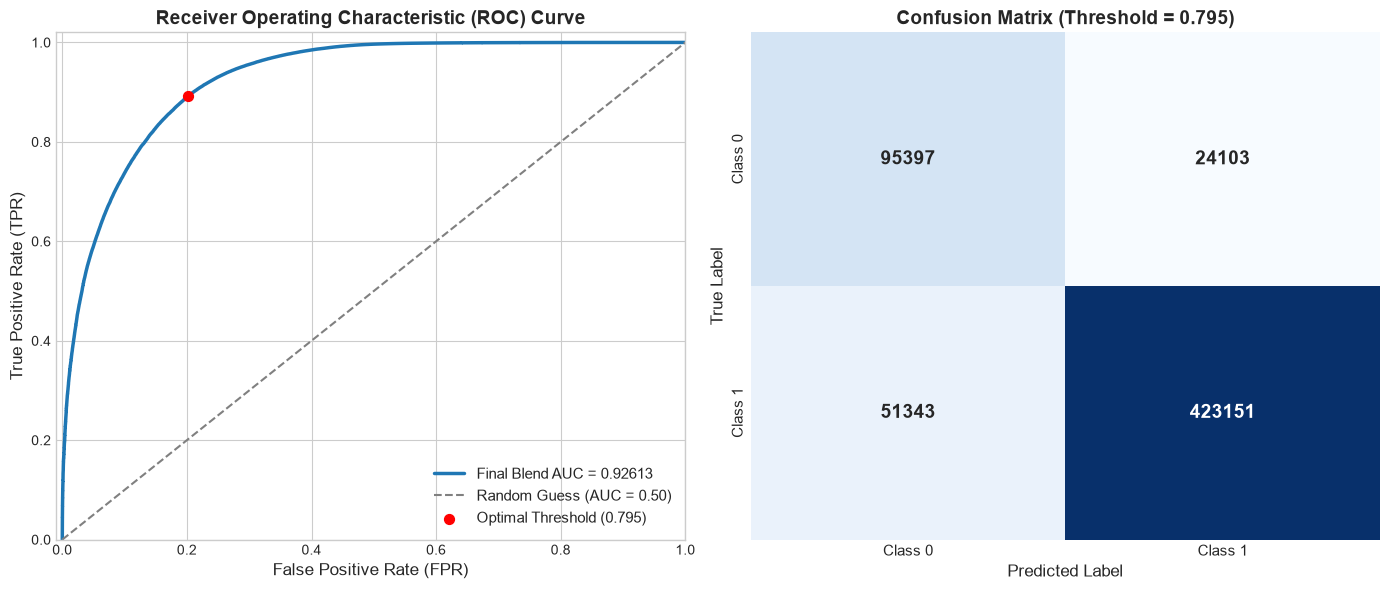

✅ Saved ensemble model successfully to 'blend_ensemble_model.pkl'


In [25]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 1. Metrics & Threshold Evaluation
auc_score = roc_auc_score(y, oof_final)
fpr, tpr, thresholds = roc_curve(y, oof_final)

# Find optimal threshold using Youden's J statistic
optimal_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[optimal_idx]

# Binarize predictions & compute Confusion Matrix
y_pred_binary = (oof_final >= best_threshold).astype(int)
cm = confusion_matrix(y, y_pred_binary)

# 2. Plotting
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: ROC Curve ---
axes[0].plot(
    fpr,
    tpr,
    color='#1f77b4',
    lw=2.5,
    label=f'Final Blend AUC = {auc_score:.5f}',
)
axes[0].plot(
    [0, 1],
    [0, 1],
    color='gray',
    linestyle='--',
    lw=1.5,
    label='Random Guess (AUC = 0.50)',
)
axes[0].scatter(
    fpr[optimal_idx],
    tpr[optimal_idx],
    color='red',
    s=50,
    zorder=5,
    label=f'Optimal Threshold ({best_threshold:.3f})',
)

axes[0].set_xlim([-0.01, 1.0])
axes[0].set_ylim([0.0, 1.02])
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[0].set_title(
    'Receiver Operating Characteristic (ROC) Curve',
    fontsize=14,
    fontweight='bold',
)
axes[0].legend(loc='lower right', fontsize=11)

# --- Plot 2: Confusion Matrix ---
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[1],
    annot_kws={'size': 14, 'weight': 'bold'},
)

axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title(
    f'Confusion Matrix (Threshold = {best_threshold:.3f})',
    fontsize=14,
    fontweight='bold',
)
axes[1].set_xticklabels(['Class 0', 'Class 1'], fontsize=11)
axes[1].set_yticklabels(['Class 0', 'Class 1'], fontsize=11)

plt.tight_layout()
plt.show()

# 3. Model Serialization
ensemble_data = {
    'lgb_model': lgb_model,
    'xgb_model': xgb_model,
    'cat_model': cat_model,
    'weights': {'w_lgb': w_lgb, 'w_xgb': w_xgb, 'w_cat': w_cat},
}

with open('blend_ensemble_model.pkl', 'wb') as f:
  pickle.dump(ensemble_data, f)

print("✅ Saved ensemble model successfully to 'blend_ensemble_model.pkl'")